In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pandarallel import pandarallel
from langdetect import detect, DetectorFactory

In [2]:
df = pd.read_csv("spotify_dataset.csv")
df = df.drop_duplicates(subset=['track_name','artists'], keep='first').reset_index(drop=True)

feature_cols = ['acousticness', 'instrumentalness', 'speechiness','energy',
                 'loudness','tempo', 'danceability', 'valence', 
                 'liveness', 'key', 'mode', 'time_signature']

data = df[feature_cols].copy() # dataset copy with just numerical values

In [3]:
from langdetect import detect, DetectorFactory
from pandarallel import pandarallel

DetectorFactory.seed = 0
pandarallel.initialize(progress_bar=True)

def get_language(row):
    text = f"{row['track_name']} {row['artists']}"

    if not text or len(text.strip()) < 3:
        return "Unknown"

    try:
        from langdetect import detect
        return detect(text) 
    except:
        return "Unknown"
    
print("Scanning track names for language")
df['language'] = df.parallel_apply(get_language, axis=1)

print(df['language'].value_counts().head())

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/
Scanning track names for language


language
en    38684
de     6924
pt     6232
es     5509
id     3366
Name: count, dtype: int64


In [ ]:
# Manual language input for test
df.at[38064, 'language'] = 'en'  
df.at[37881, 'language'] = 'en'  
df.at[9461, 'language'] = 'en'   
df.at[63200, 'language'] = 'en'  


df.at[63191, 'language'] = 'tr'  
df.at[38496, 'language'] = 'de'  



Data cleaning complete. Run get_recommendations(38064) now!


In [21]:
# Song/Artist Index Search
def find_song(query):
    return df[df['track_name'].str.contains(query, case=False) | 
              df['artists'].str.contains(query, case=False)][['track_name', 'artists']]

find_song("Ramble")

,track_name,artists
3363,To Speak Of Solitude,Brambles
3373,In The Androgynous Dark,Brambles
3693,Pink And Golden Billows,Brambles
3730,Such Owls As You,Brambles
5988,Rambler's Anthem,Yonder Mountain String Band
6775,If There's Still Ramblin' in the Rambler,Yonder Mountain String Band
9950,Midnight Rambler - Mono,The Rolling Stones
38064,Ramble On - 1990 Remaster,Led Zeppelin
66444,Ramble,Link Wray;The Wraymen


In [5]:
# Macro Genres for combining genres
macro = {
    # Classic and Hard Rock
    'rock': "Classic_Rock",
    'british': "Classic_Rock",
    'rock-n-roll': "Classic_Rock",
    'hard-rock': "Classic_Rock",
    'psych-rock': "Classic_Rock",
    'guitar': "Classic_Rock",
    
    # Alt 
    'punk': "Alt_indie",
    'alt-rock': "Alt_indie",
    'indie': "Alt_indie",
    'punk_rock': "Alt_indie",
    'grunge': "Alt_indie",
    'alternative': "Alt_indie",
    
    # Pop and synth
    'synth-pop': "Pop_synth",
    'pop': "Pop_synth",
    'power-pop': "Pop_synth",
    'piano': "Pop_synth",
    'power-pop': "Pop_synth",
    'indie-pop': "Pop_synth",
    'acoustic': "Pop_synth",
    'singer-songwriter': "Pop_synth",


    # World
    'indian': "World",
    'swedish': "World",
    'afrobeat': "World",
    'french': "World",
    'samba': "World",
    'turkish': "World",
    'latin': "World",
    'pagode': "World",
    'tango': "World",
    'world-music': "World",
    'latino': "World",
    'spanish': "World",
    'brazil': "World",
    'german': "World",
    'iranian': "World",
    'malay': "World",
    'reggaeton': "World",
    'k-pop': "World",
    'j-pop': "World",
    'j-rock': "World",
    'mandopop': "World",
    'cantopop': "World",

    # Electronic
    'edm': 'Electronic', 
    'house': 'Electronic', 
    'techno': 'Electronic',
    'trance': 'Electronic', 
    'dubstep': 'Electronic', 
    'dance': 'Electronic',
    'deep-house': 'Electronic', 
    'electronic': 'Electronic', 
    'club': 'Electronic',
    'breakbeat': 'Electronic', 
    'drum-and-bass': 'Electronic', 
    'idm': 'Electronic',

    # Metal
    'metal': 'Metal',
    'heavy-metal': 'Metal', 
    'black-metal': 'Metal',
    'death-metal': 'Metal', 
    'metalcore': 'Metal', 
    'grindcore': 'Metal',

    # Jazz, blues, soul, r&b
    'jazz': 'JBSRNB', 'blues': "JBSRNB", 'soul': "JBSRNB",
    'r-n-b': "JBSRNB", 'funk': "JBSRNB", 'disco': "JBSRNB",

    # Country and folk
    'country': 'Country_Folk', 'folk': 'Country_Folk', 'bluegrass': 'Country_Folk',
    'honky-tonk': 'Country_Folk'
}
# anything not in this list becomes "other" - edit later for greater accuracy
df['macro'] = df['track_genre'].map(lambda x: macro.get(x, "Other"))

print("Macro Genre Distribution")
print(df['macro'].value_counts())




Macro Genre Distribution
macro
Other           36123
World           16161
Electronic       7957
Metal            4707
Pop_synth        4366
Classic_Rock     3817
Country_Folk     3119
JBSRNB           2999
Alt_indie        2095
Name: count, dtype: int64


In [6]:
# Feature Engineering - scaling, one-hot encoding, and weighting
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

macro_dummies = pd.get_dummies(df['macro'], prefix='macro')

macro_weighted = macro_dummies * 2.5


In [7]:
# Tensor creation
combined_data = np.hstack([scaled_data, macro_weighted])
X = torch.tensor(combined_data).float()

In [8]:
# Data loader 
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=64, shuffle= True) # batch size use powers of 2
print(f"Data shape check: {X.shape}")

Data shape check: torch.Size([81344, 21])


Autoencoder Setup

In [9]:
class SongAutoencoder(nn.Module):
    def __init__(self, input_dimension):
        super(SongAutoencoder, self).__init__()

        # Encoder - going to squeeze 12 to 64 to 12
        # expand to 64 to find correlations then map back to 12
        self.encoder = nn.Sequential(
            nn.Linear(input_dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU()
        )

        # Decoder - reconstructing 12 features from 4
        self.decoder = nn.Sequential(
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, input_dimension)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [10]:
model = SongAutoencoder(X.shape[1])
print(model)

SongAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=12, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=21, bias=True)
  )
)


Training Loop

Epoch [30/30] complete. Error: 0.0029


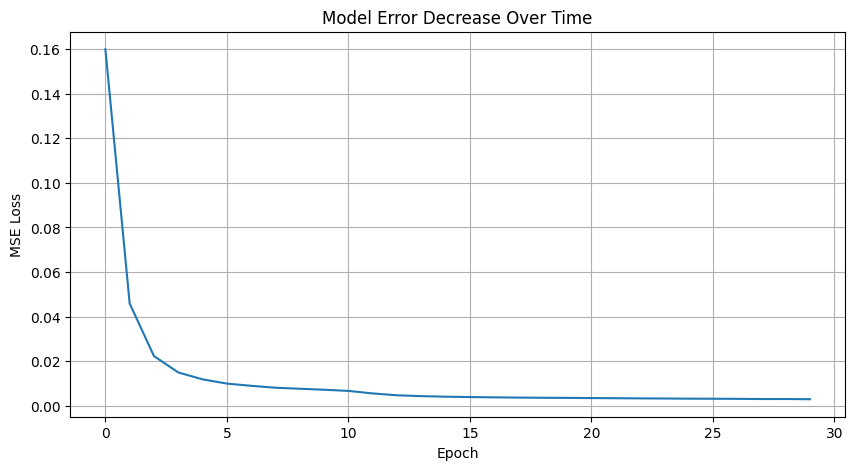

In [11]:
error_formula = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) # why this learning rate

epochs = 30
losses = []

for epoch in range(epochs):
    error_this_epoch = 0

    for batch in dataloader:
        # get one batch of songs (64 each time)
        inputs = batch[0]

        # clear gradients (memory) from previous step
        optimizer.zero_grad()

        # forward pass: model tries reconstructing song "dna"
        outputs = model(inputs)
        
        # calculate error for this specific batch
        loss = error_formula(outputs, inputs)

        # backpropagation - calculate how much to change each weight
        loss.backward()

        # update and adjust weights
        optimizer.step()

        # accumulate error to list
        error_this_epoch += loss.item()

    avg_loss = error_this_epoch / len(dataloader)
    losses.append(avg_loss)

if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch + 1}/{epochs}] complete. Error: {avg_loss:.4f}")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Model Error Decrease Over Time")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


In [12]:
# Switch model out of training mode and into evaluation
model.eval()

# Generate latent representations (embeddings) - no gradient to save memory
with torch.no_grad():
    # pass entire X tensor through just encoder part
    latent_embeddings = model.encoder(X)

# Convert to Numpy array
embedding_matrix = latent_embeddings.numpy()

print(f"Embedding Matrix Shape: {embedding_matrix.shape}")
print(f"Latent vector for first song: \n{embedding_matrix[0]}")


Embedding Matrix Shape: (81344, 12)
Latent vector for first song: 
[ 8.185086   5.4352484  6.244383   1.2621002  1.4489373  8.420666
  5.052143   7.0830517  3.3362203 11.070422   4.1988306  2.0420134]


In [26]:
# Recommender Function
from sklearn.metrics.pairwise import cosine_similarity

def get_recommendations(song_index, n_recs=5):
    # Get 4D Latent vector from base song
    # reshape into a 2d array
    query_vector = embedding_matrix[song_index].reshape(1, -1)

    # Calculate similarity score against all songs in df. 1.0 = identical, 0.0 = opposite
    similarity_scores = cosine_similarity(query_vector, embedding_matrix)[0]

    base_lang = df.iloc[song_index]['language']
    # mask
    lang_mask = (df['language'] == base_lang).astype(float)
    lang_mask[lang_mask == 0] = 0.0001

    final_scores = similarity_scores * lang_mask

    # Find indices of highest scores - use n+1 because base song will be perfect match
    top_indices = final_scores.argsort()[-(n_recs + 1):-1][::-1]

    # Display results using original uncopied dataframe:
    base_song = df.iloc[song_index]
    print(f"If you like: '{base_song["track_name"]}' by {base_song['artists']}")
    print("="*50)

    for rank, index in enumerate(top_indices, 1):
        match = df.iloc[index]
        score = final_scores[index]
        print(f"{rank}. {match['track_name']} | {match['artists']} ({score:.2%} Match)")
    
    return top_indices

top_indices = get_recommendations(38064) # reelin in the years steely dan 16788




If you like: 'Ramble On - 1990 Remaster' by Led Zeppelin
1. Don't Treat Me Bad | Firehouse (99.97% Match)
2. Break on Through (To the Other Side) | The Doors (99.95% Match)
3. The Immigrant Song - Alternate Mix | Led Zeppelin (99.93% Match)
4. Two Of Us - Remastered 2009 | The Beatles (99.93% Match)
5. Dreams | Gabrielle (99.93% Match)


In [27]:
# Check the genres of the results
df.iloc[[38064] + list(top_indices)][['track_name', 'artists', 'track_genre']]

,track_name,artists,track_genre
38064,Ramble On - 1990 Remaster,Led Zeppelin,hard-rock
38239,Don't Treat Me Bad,Firehouse,hard-rock
63090,Break on Through (To the Other Side),The Doors,psych-rock
38129,The Immigrant Song - Alternate Mix,Led Zeppelin,hard-rock
9973,Two Of Us - Remastered 2009,The Beatles,british
9461,Dreams,Gabrielle,british


In [20]:


# 1. Grab the indices from your last run
comparison_indices = [16788] + list(top_indices)

# 2. Create the vertical table
vibe_dashboard = df.iloc[comparison_indices].copy()
vibe_dashboard.set_index('track_name', inplace=True)

# 3. Transpose and highlight the "Leader" (the first column)
# We round to 3 decimals to keep it readable
vibe_dashboard = vibe_dashboard[feature_cols].T

print("Vibe Comparison Dashboard:")
display(vibe_dashboard.style.background_gradient(axis=1, cmap='viridis').format(precision=3))

Vibe Comparison Dashboard:


track_name,Reelin' In The Years,Thunderbird,Breakin' Thru,Polar Opposites,The Place That I Call Home,Gravity Rides Everything
acousticness,0.115,0.008,0.208,0.015,0.131,0.117
instrumentalness,0.000,0.026,0.000,0.003,0.007,0.003
speechiness,0.036,0.048,0.037,0.031,0.029,0.037
energy,0.758,0.780,0.721,0.834,0.730,0.877
loudness,-9.920,-8.448,-8.705,-6.413,-6.181,-7.799
tempo,135.349,130.025,129.898,131.821,128.775,122.079
danceability,0.520,0.557,0.636,0.593,0.544,0.612
valence,0.706,0.549,0.630,0.734,0.622,0.791
liveness,0.109,0.106,0.094,0.138,0.091,0.131
key,2.000,2.000,2.000,2.000,2.000,4.000


Song Search Function within dataframe with duplicates removed

Genre Lookup

In [16]:
def show_unique_genres(dataframe):
    unique_genres = sorted(dataframe['track_genre'].unique())

    print(f"Total Unique Labels: {len(unique_genres)}")
    
    # print in grid w/ 5 columns
    for i in range(0, len(unique_genres), 5):
        print(" | ".join(f"{g:<20}" for g in unique_genres[i:i+5]))

show_unique_genres(df)

Total Unique Labels: 113
acoustic             | afrobeat             | alt-rock             | alternative          | ambient             
anime                | black-metal          | bluegrass            | blues                | brazil              
breakbeat            | british              | cantopop             | chicago-house        | children            
chill                | classical            | club                 | comedy               | country             
dance                | dancehall            | death-metal          | deep-house           | detroit-techno      
disco                | disney               | drum-and-bass        | dub                  | dubstep             
edm                  | electro              | electronic           | emo                  | folk                
forro                | french               | funk                 | garage               | german              
gospel               | goth                 | grindcore            | gr

In [28]:
# Look at the seed song and your current results
audit_indices = [38064] + list(top_indices)
print("Language Tag Audit for current results:")
print("-" * 40)
print(df.loc[audit_indices][['track_name', 'artists', 'language']])

Language Tag Audit for current results:
----------------------------------------
                                 track_name       artists language
38064             Ramble On - 1990 Remaster  Led Zeppelin       en
38239                    Don't Treat Me Bad     Firehouse       en
63090  Break on Through (To the Other Side)     The Doors       en
38129    The Immigrant Song - Alternate Mix  Led Zeppelin       en
9973            Two Of Us - Remastered 2009   The Beatles       en
9461                                 Dreams     Gabrielle       en
